## S

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from dataclasses import dataclass
from typing import Optional


# -------------------------
# 手动稳定 logsumexp / log_softmax
# -------------------------

def logsumexp(x: torch.Tensor, dim: int = -1, keepdim: bool = False) -> torch.Tensor:
    m = x.max(dim=dim, keepdim=True).values
    y = m + torch.log(torch.sum(torch.exp(x - m), dim=dim, keepdim=True))
    return y if keepdim else y.squeeze(dim)

def log_softmax(x: torch.Tensor, dim: int = -1) -> torch.Tensor:
    return x - logsumexp(x, dim=dim, keepdim=True)


def softmax(x: torch.Tensor):
    m = torch.max(x, dim=-1, keepdim=True).values
    return torch.exp(x - m) / torch.sum(torch.exp(x - m), dim=-1, keepdim=True)


# -------------------------
# 手动 SFT 交叉熵（cLM）
# -------------------------

def sft_cross_entropy_loss(
    logits: torch.Tensor,      # [B, T, V]
    labels: torch.Tensor,      # [B, T]
    loss_mask: torch.Tensor,   # [B, T] 1=有效位置
) -> torch.Tensor:
    logits = logits[:, :-1, :].float()
    targets = labels[:, 1:]
    mask = loss_mask[:, 1:].float()

    logZ = logsumexp(logits, dim=-1, keepdim=False)
    tgt = torch.gather(logits, dim=-1, index=targets.unsqueeze(-1)).squeeze(-1)
    ce = logZ - tgt

    loss = (ce * mask).sum() / mask.sum().clamp_min(1.0)
    return loss

# -------------------------
# Batch & train step
# -------------------------

@dataclass
class SFTBatch:
    input_ids: torch.Tensor
    attention_mask: torch.Tensor
    labels: torch.Tensor
    loss_mask: torch.Tensor

def sft_train_step(
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    batch: SFTBatch,
    grad_accum_steps: int = 1,
    step_idx: int = 1,
) -> float:
    model.train()

    out = model(input_ids=batch.input_ids, attention_mask=batch.attention_mask)
    loss = sft_cross_entropy_loss(out.logits, batch.labels, batch.loss_mask)

    if hasattr(out, "aux_loss") and out.aux_loss is not None:
        loss = loss + out.aux_loss

    loss = loss / float(grad_accum_steps)
    loss.backward()

    if step_idx % grad_accum_steps == 0:
        optimizer.step()
        optimizer.zero_grad(set_to_none=True)

    return float(loss.detach().cpu().item() * grad_accum_steps)

# -------------------------
# 用法示例
# -------------------------
# for step_idx, batch in enumerate(loader, 1):
#     b = SFTBatch(
#         input_ids=batch["input_ids"].to(device),
#         attention_mask=batch["attention_mask"].to(device),
#         labels=batch["labels"].to(device),
#         loss_mask=batch["loss_mask"].to(device),
#     )
#     loss_val = sft_train_step(model, optimizer, b, grad_accum_steps=accum, step_idx=step_idx)

## DPO

### Mini version

In [ ]:
import torch
from torch import nn
import torch.nn.functional as F

class DPO:
    """
    图中 DPO 的核心形式：

    chosen_r = policy_chosen_logps - ref_chosen_logps
    reject_r = policy_reject_logps - ref_reject_logps
    loss = -logsigmoid(beta * (chosen_r - reject_r))

    这里的 *_logps 通常指“序列 log 概率”（对 completion token 的 logp 求和）
    """

    def __init__(self, beta: float):
        self.beta = beta

    def dpo_loss(
        self,
        policy_chosen_logps: torch.Tensor,   # [B]
        policy_reject_logps: torch.Tensor,   # [B]
        ref_chosen_logps: torch.Tensor,      # [B]
        ref_reject_logps: torch.Tensor,      # [B]
    ) -> torch.Tensor:
        """
        返回一个标量 loss（batch mean）
        """
        # “相对参考模型的提升幅度”
        chosen_r = policy_chosen_logps - ref_chosen_logps
        reject_r = policy_reject_logps - ref_reject_logps

        # 希望 chosen_r > reject_r
        # -logsigmoid(beta*(chosen_r-reject_r))：差距越大，loss 越小
        loss = -F.logsigmoid(self.beta * (chosen_r - reject_r))
        return loss.mean()
    


### Detail version

In [ ]:
import torch
import torch.nn as nn
from dataclasses import dataclass
from typing import Optional, Tuple

# -------------------------
# 手动稳定函数：logsumexp / log_softmax / softplus / log_sigmoid
# -------------------------

def logsumexp(x: torch.Tensor, dim: int = -1, keepdim: bool = False) -> torch.Tensor:
    m = x.max(dim=dim, keepdim=True).values
    y = m + torch.log(torch.sum(torch.exp(x - m), dim=dim, keepdim=True))
    return y if keepdim else y.squeeze(dim)

def log_softmax(x: torch.Tensor, dim: int = -1) -> torch.Tensor:
    return x - logsumexp(x, dim=dim, keepdim=True)

def softplus(x: torch.Tensor) -> torch.Tensor:
    return torch.clamp(x, min=0) + torch.log1p(torch.exp(-torch.abs(x)))

def log_sigmoid(x: torch.Tensor) -> torch.Tensor:
    return -softplus(-x)

# -------------------------
# 手动 token logp（cLM）
# -------------------------

def per_token_logps_from_logits(
    logits: torch.Tensor,          # [B, T, V]
    input_ids: torch.Tensor,       # [B, T]
) -> torch.Tensor:
    """
    logits[:, t] 预测 input_ids[:, t+1]
    返回 [B, T-1]
    """
    logits = logits[:, :-1, :].float()           # FP32 更稳
    targets = input_ids[:, 1:]
    lprobs = log_softmax(logits, dim=-1)
    tok = torch.gather(lprobs, dim=-1, index=targets.unsqueeze(-1)).squeeze(-1)
    return tok

def forward_token_logps(
    model: nn.Module,
    input_ids: torch.Tensor,
    attention_mask: Optional[torch.Tensor] = None,
) -> torch.Tensor:
    out = model(input_ids=input_ids, attention_mask=attention_mask)
    return per_token_logps_from_logits(out.logits, input_ids)  # [B, T-1]

def sequence_logp(token_logps: torch.Tensor, token_mask: torch.Tensor) -> torch.Tensor:
    """
    token_logps: [B, T-1]
    token_mask : [B, T-1] 1=计入（通常只计 completion）
    """
    return (token_logps * token_mask.float()).sum(dim=1)  # [B]

# -------------------------
# DPO batch
# -------------------------

@dataclass
class DPOBatch:
    chosen_input_ids: torch.Tensor        # [B, T]
    chosen_attn_mask: torch.Tensor        # [B, T]
    rejected_input_ids: torch.Tensor      # [B, T]
    rejected_attn_mask: torch.Tensor      # [B, T]
    chosen_completion_mask: torch.Tensor  # [B, T-1]
    rejected_completion_mask: torch.Tensor# [B, T-1]

# -------------------------
# 手动 DPO loss
# -------------------------

def dpo_loss(
    policy_model: nn.Module,
    ref_model: nn.Module,
    batch: DPOBatch,
    beta: float = 0.1,
) -> torch.Tensor:
    """
    DPO:
      diff = (logπ(y+) - logπ(y-)) - (logref(y+) - logref(y-))
      loss = -log sigmoid(beta * diff)
    """
    # policy logps (grad)
    pi_c_tok = forward_token_logps(policy_model, batch.chosen_input_ids, batch.chosen_attn_mask)    # [B, T-1]
    pi_r_tok = forward_token_logps(policy_model, batch.rejected_input_ids, batch.rejected_attn_mask)

    # ref logps (no grad)
    with torch.no_grad():
        rf_c_tok = forward_token_logps(ref_model, batch.chosen_input_ids, batch.chosen_attn_mask)
        rf_r_tok = forward_token_logps(ref_model, batch.rejected_input_ids, batch.rejected_attn_mask)

    # sequence logp over completion only
    pi_c = sequence_logp(pi_c_tok, batch.chosen_completion_mask)     # [B]
    pi_r = sequence_logp(pi_r_tok, batch.rejected_completion_mask)   # [B]
    rf_c = sequence_logp(rf_c_tok, batch.chosen_completion_mask)     # [B]
    rf_r = sequence_logp(rf_r_tok, batch.rejected_completion_mask)   # [B]

    diff = (pi_c - pi_r) - (rf_c - rf_r)       # [B]
    loss = (-log_sigmoid(beta * diff)).mean()  # scalar
    return loss

# -------------------------
# train step
# -------------------------

def dpo_train_step(
    policy_model: nn.Module,
    ref_model: nn.Module,
    optimizer: torch.optim.Optimizer,
    batch: DPOBatch,
    beta: float,
    grad_accum_steps: int = 1,
    step_idx: int = 1,
) -> float:
    policy_model.train()

    loss = dpo_loss(policy_model, ref_model, batch, beta=beta)
    loss = loss / float(grad_accum_steps)
    loss.backward()

    if step_idx % grad_accum_steps == 0:
        optimizer.step()
        optimizer.zero_grad(set_to_none=True)

    return float(loss.detach().cpu().item() * grad_accum_steps)

# -------------------------
# completion_mask 怎么做（提示）
# -------------------------
def make_completion_mask_from_prompt_len(prompt_len: torch.Tensor, T: int, device) -> torch.Tensor:
    """
    prompt_len: [B]（例如 attention_mask.sum(dim=1)）
    返回 [B, T-1]，1 表示对应预测位置属于 completion（k>=prompt_len）
    token_logps 的 index i 对应预测 token k=i+1
    """
    B = prompt_len.size(0)
    k = torch.arange(1, T, device=device).unsqueeze(0).expand(B, T-1)  # k=1..T-1
    return (k >= prompt_len.unsqueeze(1)).int()


## GRPO

### mini version

In [ ]:
import torch

class GRPO:
    """
    教学版 GRPO（图中写法）：

    输入一般是“按 token 或按序列聚合过的 logp”：
      old_logps: rollout 时的 logπ_old(a|s)
      new_logps: 当前 logπ(a|s)
      ref_logps: 参考模型 logπ_ref(a|s)
      advantages: 优势 A（可按组内 reward 标准化得到）

    注意：
    - 这份代码把 KL 正则写成 (exp(x) - x - 1) 的形式；
    - 其中 x = new_logps - ref_logps（图中变量名 ref_logr）。
      （它是一个常见的“非负型”正则形式，用于稳定训练；不同实现可能会用 ref-new 或 new-ref，方向会影响含义）
    """

    def __init__(self, eps: float, clip: float, beta: float):
        self.eps = eps
        self.clip = clip
        self.beta = beta

    def mask_mean(self, loss: torch.Tensor, mask: torch.Tensor, dim: int = -1) -> torch.Tensor:
        """
        对带 mask 的 loss 做平均：
          mean = Σ(loss * mask) / Σ(mask)
        """
        return (loss * mask).sum(dim=dim) / mask.sum(dim=dim)

    def group_advantage(self, rewards: torch.Tensor) -> torch.Tensor:
        """
        图中版本的“组内优势标准化”写法（对 rewards 做标准化）：
          A = (r - mean) / (std + eps)
        然后 detach，避免 reward 这条路径反传（通常 reward 来自 RM 或打分函数）。
        """
        mean = torch.mean(rewards)
        std = torch.std(rewards, unbiased=False)
        advantages = (rewards - mean) / (std + self.eps)
        return advantages.detach()

    def grpo_loss(
        self,
        old_logps: torch.Tensor,
        new_logps: torch.Tensor,
        ref_logps: torch.Tensor,
        advantages: torch.Tensor,
    ) -> torch.Tensor:
        """
        图中 loss（PPO-style）：

        ratio = exp(new - old)
        surr1 = ratio * adv
        surr2 = clamp(ratio, 1-clip, 1+clip) * adv
        kl_score = (exp(ref_logr) - ref_logr - 1) * beta
        loss = -mean(min(surr1, surr2) - kl_score)
        """
        # 重要性采样比率（token/动作级）
        ratio = torch.exp(new_logps - old_logps)

        # ref_logr：图里写的是 new_logps - ref_logps
        # （它不是“真 KL 的 vocab 求和”，而是一个用于正则的点值/估计项构造）
        ref_logr = new_logps - ref_logps

        # “非负型”KL/正则分数（图中形式）
        # 形式：exp(x) - x - 1 >= 0（对任意实数 x 都成立）
        kl_score = (torch.exp(ref_logr) - ref_logr - 1) * self.beta

        # PPO surrogate
        surr1 = ratio * advantages
        surr2 = torch.clamp(ratio, 1 - self.clip, 1 + self.clip) * advantages
        
        # maximize (min(surr1,surr2) - kl_score)  <=> minimize negative
        loss = -torch.mean(torch.min(surr1, surr2) - kl_score)
        return loss


In [ ]:
import torch
kl_beta = 0.04
epsilon = 0.2

def get_token_level_grpo_loss(logits, token_ids):
    log_probs = torch.log_softmax(logits, dim=-1) # [B, T, V]
    token_level_logps = torch.gather(log_probs, dim=-1, index=token_ids.unsqueeze(-1)).squeeze(-1) # [B, T]
    return token_level_logps
    
old_logps, ref_logps, new_logps, rewards, attention_mask = torch.randn(5, 4,8) # bsz seq_len
exp_diff_ref = new_logps - ref_logps
kl_k3 = torch.exp(exp_diff_ref) - exp_diff_ref - 1
ratio = torch.exp(new_logps - old_logps)
adv = (rewards - torch.mean(rewards, dim=-1, keepdim=True)) / torch.sqrt(torch.mean(torch.pow(rewards - torch.mean(rewards, dim=-1, keepdim=True), 2), dim=-1, keepdim=True) + 1e-8)
loss = torch.min(ratio * adv, torch.clamp(ratio, 1 - epsilon, 1 + epsilon) * adv) - kl_beta * kl_k3
final_loss =  -(torch.sum(attention_mask * loss)/ torch.sum(attention_mask).clamp(min=1.0))

### Detail version

In [ ]:
import torch
import torch.nn as nn
from dataclasses import dataclass
from typing import Callable, Dict, Optional, Tuple

# =========================
# 1) 手动稳定数值函数
# =========================

def logsumexp(x: torch.Tensor, dim: int = -1, keepdim: bool = False) -> torch.Tensor:
    m = x.max(dim=dim, keepdim=True).values
    y = m + torch.log(torch.sum(torch.exp(x - m), dim=dim, keepdim=True))
    return y if keepdim else y.squeeze(dim)

def log_softmax(x: torch.Tensor, dim: int = -1) -> torch.Tensor:
    return x - logsumexp(x, dim=dim, keepdim=True)

def masked_mean(x: torch.Tensor, mask: torch.Tensor, dim: int) -> torch.Tensor:
    mask_f = mask.float()
    num = torch.sum(x * mask_f, dim=dim)
    den = torch.sum(mask_f, dim=dim).clamp_min(1.0)
    return num / den

# =========================
# 2) token 级 logprob（手动）
# =========================

def per_token_logps_from_logits(logits: torch.Tensor, input_ids: torch.Tensor) -> torch.Tensor:
    """
    logits[:, t] 预测 input_ids[:, t+1]
    返回 [B, T-1] 的 next-token logp
    """
    logits = logits[:, :-1, :].float()              # [B, T-1, V]  (FP32 更稳)
    targets = input_ids[:, 1:]                      # [B, T-1]
    lprobs = log_softmax(logits, dim=-1)            # [B, T-1, V]
    tok = torch.gather(lprobs, -1, targets.unsqueeze(-1)).squeeze(-1)  # [B, T-1]
    return tok

@torch.no_grad()
def forward_token_logps_no_grad(model: nn.Module, input_ids: torch.Tensor, attention_mask: Optional[torch.Tensor]=None):
    out = model(input_ids=input_ids, attention_mask=attention_mask)
    token_logps = per_token_logps_from_logits(out.logits, input_ids)
    return token_logps

def forward_token_logps(model: nn.Module, input_ids: torch.Tensor, attention_mask: Optional[torch.Tensor]=None):
    out = model(input_ids=input_ids, attention_mask=attention_mask)
    token_logps = per_token_logps_from_logits(out.logits, input_ids)
    return token_logps

# =========================
# 3) 生成 & mask（教学用）
# =========================

@torch.no_grad()
def naive_generate(
    model: nn.Module,
    prompt_input_ids: torch.Tensor,      # [B, P]
    prompt_attn_mask: torch.Tensor,      # [B, P]
    num_return_sequences: int,
    max_new_tokens: int,
    temperature: float,
    eos_token_id: int,
) -> torch.Tensor:
    """
    教学用 naive sampling：不缓存 KV，很慢。
    输出: [B*G, P+R]（R固定：直到所有序列都遇到 eos 或达到 max_new_tokens）
    """
    model.eval()
    device = prompt_input_ids.device
    B, P = prompt_input_ids.shape
    G = num_return_sequences

    input_ids = prompt_input_ids.repeat_interleave(G, dim=0)  # [B*G, P]
    attn_mask = prompt_attn_mask.repeat_interleave(G, dim=0)  # [B*G, P]

    for _ in range(max_new_tokens):
        out = model(input_ids=input_ids, attention_mask=attn_mask)
        logits = out.logits[:, -1, :].float()  # [B*G, V]
        logits = logits / max(temperature, 1e-6)
        probs = torch.exp(log_softmax(logits, dim=-1))         # softmax

        next_ids = torch.multinomial(probs, num_samples=1).squeeze(1)  # [B*G]
        input_ids = torch.cat([input_ids, next_ids.unsqueeze(1)], dim=1)
        attn_mask = torch.cat([attn_mask, torch.ones_like(next_ids).unsqueeze(1)], dim=1)

        if (next_ids == eos_token_id).all():
            break

    return input_ids

def build_completion_mask(completion_ids: torch.Tensor, eos_token_id: int) -> torch.Tensor:
    """
    completion_ids: [N, R]
    mask: 0..eos(含) 为 1，其后为 0
    """
    N, R = completion_ids.shape
    is_eos = (completion_ids == eos_token_id)  # [N, R]
    eos_idx = torch.full((N,), R, dtype=torch.long, device=completion_ids.device)
    has = is_eos.any(dim=1)
    eos_idx[has] = is_eos.int().argmax(dim=1)[has]
    ar = torch.arange(R, device=completion_ids.device).unsqueeze(0).expand(N, R)
    return (ar <= eos_idx.unsqueeze(1)).int()

# =========================
# 4) GRPO + PPO-clip 配置
# =========================

@dataclass
class GRPOConfig:
    num_generations: int = 4
    max_new_tokens: int = 256
    temperature: float = 0.8

    beta_kl: float = 0.02          # KL 系数
    adv_clip: float = 10.0

    use_ppo_clip: bool = False     # 关键开关
    clip_eps: float = 0.2
    update_epochs: int = 2
    minibatch_size: int = 4
    shuffle: bool = True

# =========================
# 5) Rollout：固定数据 + 缓存 logp_old
# =========================

@torch.no_grad()
def grpo_rollout_batch(
    policy_model: nn.Module,
    ref_model: nn.Module,
    prompt_input_ids: torch.Tensor,    # [B, P]
    prompt_attn_mask: torch.Tensor,    # [B, P]
    reward_fn: Callable[[torch.Tensor], torch.Tensor],  # reward_fn(seqs)->[B*G]
    cfg: GRPOConfig,
    eos_token_id: int,
) -> Dict[str, torch.Tensor]:
    """
    返回一个“可复用”的 batch：
      seqs: [B*G, T]
      completion_mask: [B*G, R]
      advantages: [B*G]
      logp_old: [B*G, R]        (policy 在 rollout 权重下，对 completion token 的 logp)
      ref_logp: [B*G, R]        (ref 对 completion token 的 logp)
      prompt_len: int
    """
    policy_model.eval()
    ref_model.eval()

    B = prompt_input_ids.size(0)
    G = cfg.num_generations
    P = prompt_input_ids.size(1)

    seqs = naive_generate(
        policy_model, prompt_input_ids, prompt_attn_mask,
        num_return_sequences=G,
        max_new_tokens=cfg.max_new_tokens,
        temperature=cfg.temperature,
        eos_token_id=eos_token_id,
    )  # [B*G, T]

    T = seqs.size(1)
    R = T - P
    completion_ids = seqs[:, P:]                    # [B*G, R]
    completion_mask = build_completion_mask(completion_ids, eos_token_id)  # [B*G, R]

    rewards = reward_fn(seqs).to(seqs.device)       # [B*G]

    # group-relative advantage
    grouped = rewards.view(B, G)
    mean_r = grouped.mean(dim=1, keepdim=True)
    std_r = grouped.std(dim=1, keepdim=True).clamp_min(1e-4)
    adv = ((grouped - mean_r) / std_r).view(B * G)
    adv = torch.clamp(adv, -cfg.adv_clip, cfg.adv_clip)
    adv = (adv - adv.mean()) / adv.std().clamp_min(1e-8)

    # 计算 token logps（next-token），然后切出 completion 对应部分
    # token_logps 的 index i 对应预测 token k=i+1
    # completion token 的 k >= P  ==> i >= P-1
    start = max(P - 1, 0)

    pi_token_logps_old = forward_token_logps_no_grad(policy_model, seqs, None)  # [B*G, T-1]
    rf_token_logps = forward_token_logps_no_grad(ref_model, seqs, None)         # [B*G, T-1]

    logp_old = pi_token_logps_old[:, start:start + R]   # [B*G, R]
    ref_logp = rf_token_logps[:, start:start + R]       # [B*G, R]

    return {
        "seqs": seqs,
        "completion_mask": completion_mask,
        "advantages": adv,
        "logp_old": logp_old,
        "ref_logp": ref_logp,
        "prompt_len": torch.tensor(P, device=seqs.device),
    }

# =========================
# 6) Update：on-policy 或 PPO-clip
# =========================

def grpo_loss_on_minibatch(
    policy_model: nn.Module,
    mb: Dict[str, torch.Tensor],
    cfg: GRPOConfig,
) -> torch.Tensor:
    """
    输入 minibatch（seqs、mask、adv、logp_old、ref_logp），输出标量 loss
    """
    seqs = mb["seqs"]                         # [N, T]
    completion_mask = mb["completion_mask"]   # [N, R]
    adv = mb["advantages"]                    # [N]
    logp_old = mb["logp_old"]                 # [N, R]
    ref_logp = mb["ref_logp"]                 # [N, R]
    P = int(mb["prompt_len"].item())
    R = completion_mask.size(1)
    start = max(P - 1, 0)

    # new logp（可反传）
    pi_token_logps_new = forward_token_logps(policy_model, seqs, None)  # [N, T-1]
    logp_new = pi_token_logps_new[:, start:start + R]                   # [N, R]

    if cfg.use_ppo_clip:
        # PPO ratio + clip
        ratio = torch.exp((logp_new - logp_old).clamp(-20, 20))  # 适度 clamp 防数值炸（教学可保留）
        surr1 = ratio * adv.unsqueeze(1)
        surr2 = torch.clamp(ratio, 1 - cfg.clip_eps, 1 + cfg.clip_eps) * adv.unsqueeze(1)
        pg_term = torch.minimum(surr1, surr2)   # maximize -> loss 用负号
    else:
        # 你之前那种“数值=1，梯度=∇logp”的 on-policy 单步写法
        pg_scale = torch.exp(logp_new - logp_new.detach())  # == 1
        pg_term = pg_scale * adv.unsqueeze(1)

    # KL(π||ref) 的采样估计（非负形式），用 ref_logp 和 logp_new
    kl_div = ref_logp - logp_new               # log(q/p)
    per_token_kl = torch.exp(kl_div) - kl_div - 1

    # 总目标：maximize (pg_term - beta * KL) => minimize -(pg_term - beta*KL)
    per_token_loss = -(pg_term - cfg.beta_kl * per_token_kl)  # [N, R]

    loss_seq = masked_mean(per_token_loss, completion_mask, dim=1)      # [N]
    return loss_seq.mean()

def grpo_update(
    policy_model: nn.Module,
    optimizer: torch.optim.Optimizer,
    rollout_batch: Dict[str, torch.Tensor],
    cfg: GRPOConfig,
    grad_accum_steps: int = 1,
) -> float:
    """
    如果 use_ppo_clip=True：对同一 rollout_batch 做 update_epochs 轮、按 minibatch_size 复用。
    如果 False：等价于 update_epochs=1 且不复用（也可以照样走下面逻辑）。
    返回：最后一个 epoch 的平均 loss（float）
    """
    policy_model.train()
    device = rollout_batch["seqs"].device
    N = rollout_batch["seqs"].size(0)

    indices = torch.arange(N, device=device)
    last_epoch_loss = 0.0

    epochs = cfg.update_epochs if cfg.use_ppo_clip else 1

    step_counter = 0
    for ep in range(epochs):
        if cfg.shuffle:
            indices = indices[torch.randperm(N, device=device)]

        # minibatch loop
        ep_losses = []
        for i in range(0, N, cfg.minibatch_size):
            mb_idx = indices[i:i + cfg.minibatch_size]
            mb = {
                "seqs": rollout_batch["seqs"][mb_idx],
                "completion_mask": rollout_batch["completion_mask"][mb_idx],
                "advantages": rollout_batch["advantages"][mb_idx],
                "logp_old": rollout_batch["logp_old"][mb_idx],
                "ref_logp": rollout_batch["ref_logp"][mb_idx],
                "prompt_len": rollout_batch["prompt_len"],
            }

            loss = grpo_loss_on_minibatch(policy_model, mb, cfg) / float(grad_accum_steps)
            loss.backward()
            ep_losses.append(loss.detach().float().item() * float(grad_accum_steps))

            step_counter += 1
            if step_counter % grad_accum_steps == 0:
                optimizer.step()
                optimizer.zero_grad(set_to_none=True)

        last_epoch_loss = sum(ep_losses) / max(len(ep_losses), 1)

    return float(last_epoch_loss)

# =========================
# 7) 用法示例
# =========================
# rollout = grpo_rollout_batch(policy_model, ref_model, prompt_ids, prompt_mask, reward_fn, cfg, eos_id)
# loss_val = grpo_update(policy_model, optimizer, rollout, cfg, grad_accum_steps=1)


## PPO Mini

In [ ]:
import torch
from torch import nn
from torch.nn import functional as F



class PPO:
    """
    图中 PPO 版本包含：
    1) mask_mean：mask 加权平均
    2) advantage_estimate：GAE（广义优势估计）
    3) policy_loss：PPO clip policy loss
    4) value_loss：value function MSE loss
    """

    def __init__(self, clip: float = 0.2, gamma: float = 0.99, lam: float = 0.95):
        self.clip = clip
        self.gamma = gamma
        self.lam = lam

    def mask_mean(self, loss: torch.Tensor, mask: torch.Tensor, dim: int = -1) -> torch.Tensor:
        """
        (loss * mask).sum / mask.sum
        mask 一般为 0/1，表示哪些 token/位置有效
        """
        return (loss * mask).sum(dim=dim) / mask.sum(dim=dim).clamp(min=1.0)

    def advantage_estimate(self, rewards: torch.Tensor, values: torch.Tensor):
        """
        GAE 广义优势估计（图中版本）：

        rewards: [B, T]
        values : [B, T]  （V(s_t)）
        输出：
          advantages: [B, T]
          returns   : [B, T] = advantages + values （相当于 target value）
        """
        seq_len = values.shape[1]
        advantages = torch.zeros_like(rewards)

        gae = 0.0  # 可以是标量；在逐步循环中会变成张量广播/累积
        for i in range(seq_len - 1, -1, -1):
            # V(s_{t+1})：最后一步没有 next_value，置 0
            next_value = values[:, i + 1] if i < seq_len - 1 else 0.0

            # TD 残差 δ_t = r_t + γ V(s_{t+1}) - V(s_t)
            delta = rewards[:, i] + self.gamma * next_value - values[:, i]

            # GAE 递推：gae_t = δ_t + γλ * gae_{t+1}
            gae = delta + self.lam * self.gamma * gae

            advantages[:, i] = gae

        # return = advantage + value
        returns = advantages + values
        return advantages, returns

    def policy_loss(
        self,
        new_probs: torch.Tensor,   # 实际上这里通常是 new_logps（对数概率）
        old_probs: torch.Tensor,   # old_logps
        advantages: torch.Tensor,  # advantage
        act_mask: torch.Tensor,    # mask（哪些位置有效）
    ) -> torch.Tensor:
        """
        PPO clip policy loss（图中写法）：

        ratio = exp(new - old)
        surr1 = ratio * adv
        surr2 = clamp(ratio, 1-clip, 1+clip) * adv
        loss = -min(surr1, surr2)
        return mask_mean(loss, act_mask)
        """
        ratio = torch.exp(new_probs - old_probs)
        surr1 = ratio * advantages
        surr2 = torch.clamp(ratio, 1 - self.clip, 1 + self.clip) * advantages
        loss = -torch.min(surr1, surr2)
        return self.mask_mean(loss, act_mask)

    def value_loss(
        self,
        new_values: torch.Tensor,  # V_theta(s)
        returns: torch.Tensor,     # target
        act_mask: torch.Tensor,
    ) -> torch.Tensor:
        """
        value function MSE:
          (V(s) - returns)^2
        """
        loss = (new_values - returns) ** 2
        return self.mask_mean(loss, act_mask)





In [ ]:
def ce_loss(logits: torch.Tensor, targets: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
    """
    手动交叉熵损失（图中写法）：

    logits: [B, T, V]
    targets: [B, T]  (token ids)
    mask: [B, T]     (0/1，表示哪些位置有效)

    loss = logsumexp(logits) - logits[target]
    return mask_mean(loss, mask)
    """
    logits = logits.float()  # FP32 更稳
    lprobs = log_softmax(logits, dim=-1)  # [B, T, V]
    tgt_logp = torch.gather(lprobs, dim=-1, index=targets.unsqueeze(-1)).squeeze(-1)  # [B, T]
    loss = -tgt_logp  # 交叉熵损失
    return loss * mask.float() / mask.sum(dim=1, keepdim=True).clamp_min(1.0)  # mask 平均

torch.Size([4])
tensor([[ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.

## DAPO

**DAPO** (Decoupled Clip and Dynamic Sampling Policy Optimization) 是字节跳动联合清华提出的 RL 算法，
在 Qwen2.5-32B 上达到 AIME 2024 50分。

论文：[arXiv:2503.14476](https://arxiv.org/abs/2503.14476)

### Mini version

In [ ]:
import torch

class DAPO:
    """
    DAPO: Decoupled Clip and Dynamic Sampling Policy Optimization
    
    四个关键技术:
    1. Clip-Higher: 解耦上下界 (ε_low=0.2, ε_high=0.28)
    2. Dynamic Sampling: 过滤 accuracy=0/1 的样本
    3. Token-Level Loss: 按 token 聚合
    4. Overlong Reward Shaping: 超长样本惩罚
    """
    def __init__(self, eps_low: float = 0.2, eps_high: float = 0.28, beta: float = 0.01):
        self.eps_low = eps_low
        self.eps_high = eps_high  # 上界更高，允许更多探索
        self.beta = beta

    def dapo_loss(self, old_logps, new_logps, ref_logps, advantages, mask):
        """
        DAPO Loss = -min(ratio*adv, clip(ratio, 1-ε_low, 1+ε_high)*adv) + β*KL
        
        关键区别: clip 上界 0.28 > 下界 0.2
        """
        ratio = torch.exp(new_logps - old_logps)
        surr1 = ratio * advantages
        surr2 = torch.clamp(ratio, 1 - self.eps_low, 1 + self.eps_high) * advantages
        pg_loss = -torch.min(surr1, surr2)
        
        kl = (torch.exp(ref_logps - new_logps) - (ref_logps - new_logps) - 1) * self.beta
        return (pg_loss + kl * mask).sum() / mask.sum().clamp(min=1.0)


# 对比 GRPO vs DAPO
B, T = 4, 100
old_logps = torch.randn(B, T)
new_logps = torch.randn(B, T)
ref_logps = torch.randn(B, T)
advantages = torch.randn(B, T)
mask = torch.ones(B, T)

# GRPO: 统一 clip [0.8, 1.2]
ratio_grpo = torch.exp(new_logps - old_logps)
surr_grpo = torch.clamp(ratio_grpo, 0.8, 1.2)
print(f"GRPO clip: [1-0.2, 1+0.2] = [0.8, 1.2]")

# DAPO: 解耦 clip [0.8, 1.28]
dapo = DAPO()
loss_dapo = dapo.dapo_loss(old_logps, new_logps, ref_logps, advantages, mask)
print(f"DAPO clip: [1-0.2, 1+0.28] = [0.8, 1.28]  # 上界更高!")
print(f"DAPO loss: {loss_dapo.item():.4f}")

## SGD 

In [ ]:
import numpy as np

np.random.seed(42)  # 保证可复现



# ============ SwiGLU 激活函数 ============
def silu(x):
    """Swish/SiLU: x * sigmoid(x)"""
    return x * (1 / (1 + np.exp(-x)))


def silu_backward(x):
    """SiLU 的导数: sigmoid(x) + x * sigmoid(x) * (1 - sigmoid(x))"""
    sig = 1 / (1 + np.exp(-x))
    return sig + x * sig * (1 - sig)



def adam_mlp2(X, y, hidden_dim=64, lr=0.01, epochs=100, batch_size=32,
              beta1=0.9, beta2=0.999, eps=1e-8, weight_decay=0.01):
    """
    Adam 优化的 2 层 MLP（MSE 回归）
    
    架构: X -> Linear -> ReLU -> Linear -> y_pred
    Loss: MSE = mean((y_pred - y)^2)
    """
    
    n_samples, n_features = X.shape
    
    # ============ He 初始化（适合 ReLU）============
    W1 = np.random.randn(n_features, hidden_dim) * np.sqrt(2 / n_features)
    b1 = np.zeros(hidden_dim)
    W2 = np.random.randn(hidden_dim, 1) * np.sqrt(2 / hidden_dim)
    b2 = np.zeros(1)
    
    # ============ Adam 一阶矩 m 和二阶矩 v ============
    m_W1, v_W1 = np.zeros_like(W1), np.zeros_like(W1)
    m_b1, v_b1 = np.zeros_like(b1), np.zeros_like(b1)
    m_W2, v_W2 = np.zeros_like(W2), np.zeros_like(W2)
    m_b2, v_b2 = np.zeros_like(b2), np.zeros_like(b2)
    t = 0  # 时间步，用于 bias correction
    
    losses = []
    
    for epoch in range(epochs):
        idx = np.random.permutation(n_samples)
        epoch_loss = 0.0
        n_batches = 0
        
        for i in range(0, n_samples, batch_size):
            t += 1
            Xb = X[idx[i:i+batch_size]]
            yb = y[idx[i:i+batch_size]].reshape(-1, 1)
            
            # ==================== Forward ====================
            # z1 = Xb @ W1 + b1       shape: (batch, hidden)
            # h1 = ReLU(z1)           shape: (batch, hidden)
            # yp = h1 @ W2 + b2       shape: (batch, 1)
            # loss = mean((yp - yb)^2)
            
            z1 = Xb @ W1 + b1
            h1 = np.maximum(0, z1)  # ReLU 
            yp = h1 @ W2 + b2
            
            batch_loss = np.mean((yp - yb) ** 2)
            epoch_loss += batch_loss
            n_batches += 1
            
            # ==================== Backward ====================
            """
            推导过程:
            
            Loss = (1/n) * Σ(yp - y)^2
            
            【Layer 2】
            ∂L/∂yp = (2/n) * (yp - y)              shape: (batch, 1)
            
            ∂L/∂W2 = ∂L/∂yp · ∂yp/∂W2 
                   = h1.T @ ∂L/∂yp                  shape: (hidden, 1)
            
            ∂L/∂b2 = ∂L/∂yp · ∂yp/∂b2 
                   = sum(∂L/∂yp, axis=0)            shape: (1,)
            
            【Layer 1】
            ∂L/∂h1 = ∂L/∂yp · ∂yp/∂h1 
                   = ∂L/∂yp @ W2.T                  shape: (batch, hidden)
            
            ∂L/∂z1 = ∂L/∂h1 · ∂h1/∂z1 
                   = ∂L/∂h1 * ReLU'(z1) 
                   = ∂L/∂h1 * (z1 > 0)              shape: (batch, hidden)
            
            ∂L/∂W1 = ∂L/∂z1 · ∂z1/∂W1 
                   = Xb.T @ ∂L/∂z1                  shape: (features, hidden)
            
            ∂L/∂b1 = sum(∂L/∂z1, axis=0)            shape: (hidden,)
            """
            
            # Layer 2 梯度
            loss_grad = 2 / len(Xb) * (yp - yb)  # ∂L/∂yp
            
            dW2 = h1.T @ loss_grad               # ∂L/∂W2
            db2 = np.sum(loss_grad, axis=0)      # ∂L/∂b2
            
            # Layer 1 梯度
            dz1 = (loss_grad @ W2.T) * (z1 > 0)  # ∂L/∂z1 = ∂L/∂h1 * ReLU'
            dW1 = Xb.T @ dz1                     # ∂L/∂W1
            db1 = np.sum(dz1, axis=0)            # ∂L/∂b1
            
            # ==================== Adam 更新 ====================
            """
            Adam 更新规则:
            m_t = β1 * m_{t-1} + (1-β1) * g_t        一阶矩（动量）
            v_t = β2 * v_{t-1} + (1-β2) * g_t^2      二阶矩（RMSprop）
            m_hat = m_t / (1 - β1^t)                 bias correction
            v_hat = v_t / (1 - β2^t)                 bias correction
            θ = θ - lr * m_hat / (√v_hat + ε)        参数更新
            
            Weight Decay (AdamW 风格):
            θ = θ - lr * (m_hat / (√v_hat + ε) + λ * θ)
            """
            
            for param, grad, m_p, v_p in [
                (W1, dW1, m_W1, v_W1), (b1, db1, m_b1, v_b1),
                (W2, dW2, m_W2, v_W2), (b2, db2, m_b2, v_b2),
            ]:
                # 更新一阶矩和二阶矩
                m_p[:] = beta1 * m_p + (1 - beta1) * grad
                v_p[:] = beta2 * v_p + (1 - beta2) * (grad ** 2)
                
                # Bias correction（修正初始零偏置）
                m_hat = m_p / (1 - beta1 ** t)
                v_hat = v_p / (1 - beta2 ** t)
                
                # Weight decay 只用于权重，不用 bias
                wd = weight_decay if param.ndim == 2 else 0
                
                # 参数更新
                param -= lr * (m_hat / (np.sqrt(v_hat) + eps) + wd * param)
        
        losses.append(epoch_loss / n_batches)
    
    return W1, b1, W2, b2, losses


def mean_squared_error(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)


# ============ 测试代码 ============
X_train = np.random.randn(100, 10)
y_train = np.random.randn(100)
X_test = np.random.randn(20, 10)
y_test = np.random.randn(20)

# 对比 ReLU MLP 和 SwiGLU MLP
print("=" * 50)
print("ReLU MLP:")
W1, b1, W2, b2, losses_relu = adam_mlp2(X_train, y_train, hidden_dim=32, lr=0.01, epochs=50)
z1 = X_test @ W1 + b1
y_pred_relu = (np.maximum(0, z1) @ W2 + b2).ravel()
print(f"Test MSE = {mean_squared_error(y_test, y_pred_relu):.4f}")
print(f"Train loss: {losses_relu[0]:.4f} -> {losses_relu[-1]:.4f}")

# print("\n" + "=" * 50)
# print("SwiGLU MLP:")
# params_swiglu, losses_swiglu = adam_mlp_swiglu(X_train, y_train, hidden_dim=32, lr=0.01, epochs=50)
# z_gate = X_test @ params_swiglu['W_gate'] + params_swiglu['b_gate']
# z_up = X_test @ params_swiglu['W_up'] + params_swiglu['b_up']
# h_test = silu(z_gate) * z_up
# y_pred_swiglu = (h_test @ params_swiglu['W_down'] + params_swiglu['b_down']).ravel()
# print(f"Test MSE = {mean_squared_error(y_test, y_pred_swiglu):.4f}")
# print(f"Train loss: {losses_swiglu[0]:.4f} -> {losses_swiglu[-1]:.4f}")

In [ ]:
import torch

weight = torch.nn.Parameter(torch.randn(10, 5))
weight = torch.randn(10, 5).requires_grad_()
print(weight)



## RLs

1. Q-Learning：离线策略，Q(s,a) += lr*(r+γmaxQ'-Q)
2. DQN：经验回放 + 目标网络 + MSE 损失
3. REINFORCE：回合更新，折扣回报归一化，loss=-Σlogπ*R
4. SAC：双 Q + 最大熵 + 重参数化 + 软更新

In [ ]:
import numpy as np
import gymnasium as gym

# 超参
lr = 0.1
gamma = 0.9
epsilon = 0.1
episodes = 500

env = gym.make("CliffWalking-v1")
n_states = env.observation_space.n
n_actions = env.action_space.n

# Q表
Q = np.zeros((n_states, n_actions))

for _ in range(episodes):
    state, _ = env.reset()
    done = False
    while not done:
        # epsilon贪心
        if np.random.uniform() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(Q[state])
        
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        
        # Q学习更新公式
        print("cur Q Table: ", Q)
        print(f"cur reward: {reward}, cur_state: {state}, action: {action}, next_state: {next_state}")
        print("#" * 100)
        Q[state, action] = Q[state, action] + lr * (
            reward + gamma * np.max(Q[next_state]) - Q[state, action]
        )
        state = next_state

In [ ]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque

class DQN(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(state_dim, 64), nn.ReLU(),
            nn.Linear(64, action_dim)
        )
    def forward(self, x):
        return self.fc(x)

# 超参
gamma = 0.99
lr = 1e-3
epsilon = 0.1
buffer_size = 10000
batch_size = 32
target_update = 10

env = gym.make("CartPole-v1")
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

net = DQN(state_dim, action_dim)
target_net = DQN(state_dim, action_dim)
target_net.load_state_dict(net.state_dict())
optimizer = optim.Adam(net.parameters(), lr=lr)
buffer = deque(maxlen=buffer_size)

for episode in range(500):
    state, _ = env.reset()
    total_reward = 0
    while True:
        # 选动作
        if random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = net(torch.FloatTensor(state)).argmax().item()
        
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        buffer.append((state, action, reward, next_state, done))
        
        total_reward += reward
        state = next_state
        
        # 训练
        if len(buffer) > batch_size:
            batch = random.sample(buffer, batch_size)
            s, a, r, s_, done = zip(*batch)
            s = torch.FloatTensor(s)
            a = torch.LongTensor(a).unsqueeze(1)
            r = torch.FloatTensor(r).unsqueeze(1)
            s_ = torch.FloatTensor(s_)
            done = torch.FloatTensor(done).unsqueeze(1)
            
            q = net(s).gather(1, a)
            max_q = target_net(s_).max(1, keepdim=True)[0]
            target_q = r + gamma * max_q * (1 - done)
            
            loss = nn.MSELoss()(q, target_q)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        print(f"Episode {episode}, Total Reward: {total_reward}")
        print(f"Buffer Size: {len(buffer)}, Loss: {loss.item() if 'loss' in locals() else 'N/A'}")
        print(done)
        if not isinstance(done, bool):
            break
    
    # 更新目标网络
    if episode % target_update == 0:
        target_net.load_state_dict(net.state_dict())

In [1]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim

class Policy(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(state_dim, 64), nn.ReLU(),
            nn.Linear(64, action_dim), nn.Softmax(dim=-1)
        )
    def forward(self, x):
        return self.fc(x)

gamma = 0.99
lr = 1e-3

env = gym.make("CartPole-v1")
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

policy = Policy(state_dim, action_dim)
optimizer = optim.Adam(policy.parameters(), lr=lr)

for episode in range(1000):
    state, _ = env.reset()
    log_probs = []
    rewards = []
    
    while True:
        prob = policy(torch.FloatTensor(state))
        action = torch.multinomial(prob, 1).item()
        log_prob = torch.log(prob[action])
        
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        
        log_probs.append(log_prob)
        rewards.append(reward)
        state = next_state
        
        if done:
            # 计算折扣回报
            returns = []
            R = 0
            for r in reversed(rewards):
                R = r + gamma * R
                returns.insert(0, R)
            returns = torch.tensor(returns)
            returns = (returns - returns.mean()) / (returns.std() + 1e-8)
            
            # 策略梯度损失
            loss = -torch.sum(torch.stack(log_probs) * returns)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            break

In [ ]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal
import random
from collections import deque

# 双Q网络
class QNet(nn.Module):
    def __init__(self, s_dim, a_dim):
        super().__init__()
        self.q1 = nn.Sequential(nn.Linear(s_dim+a_dim,64),nn.ReLU(),nn.Linear(64,1))
        self.q2 = nn.Sequential(nn.Linear(s_dim+a_dim,64),nn.ReLU(),nn.Linear(64,1))
    def forward(self, s, a):
        x = torch.cat([s,a],1)
        return self.q1(x), self.q2(x)

# 策略网络
class Actor(nn.Module):
    def __init__(self, s_dim, a_dim, max_a):
        super().__init__()
        self.max_a = max_a
        self.fc = nn.Sequential(nn.Linear(s_dim,64),nn.ReLU())
        self.mean = nn.Linear(64, a_dim)
        self.log_std = nn.Linear(64, a_dim)
    def forward(self, s):
        x = self.fc(s)
        mean = self.mean(x)
        log_std = torch.clamp(self.log_std(x),-20,2)
        return mean, log_std
    def sample(self, s):
        mean, log_std = self.forward(s)
        dist = Normal(mean, log_std.exp())
        x = dist.rsample()
        y = torch.tanh(x)
        log_prob = dist.log_prob(x) - torch.log(1-y.pow(2)+1e-6)
        return y*self.max_a, log_prob.sum(1,keepdim=True)

# 训练
gamma=0.99;tau=0.005;lr=3e-4
env = gym.make("Pendulum-v1")
s_dim = env.observation_space.shape[0]
a_dim = env.action_space.shape[0]
max_a = env.action_space.high[0]

q_net = QNet(s_dim,a_dim)
q_target = QNet(s_dim,a_dim)
q_target.load_state_dict(q_net.state_dict())
actor = Actor(s_dim,a_dim,max_a)

q_opt = optim.Adam(q_net.parameters(),lr=lr)
a_opt = optim.Adam(actor.parameters(),lr=lr)
buffer = deque(maxlen=10000)

for episode in range(1000):
    s,_ = env.reset()
    while True:
        a,_ = actor.sample(torch.FloatTensor(s).unsqueeze(0))
        a = a.detach().numpy()[0]
        s_,r,terminated,truncated,_ = env.step(a)
        done = terminated or truncated
        buffer.append((s,a,r,s_,done))
        s = s_
        
        if len(buffer)>32:
            batch = random.sample(buffer,32)
            s,a,r,s_,done = zip(*batch)
            s = torch.FloatTensor(s)
            a = torch.FloatTensor(a)
            r = torch.FloatTensor(r).unsqueeze(1)
            s_ = torch.FloatTensor(s_)
            done = torch.FloatTensor(done).unsqueeze(1)
            
            # 更新Q
            a_,log_p = actor.sample(s_)
            q1_t,q2_t = q_target(s_,a_)
            target_q = r+gamma*(1-done)*(torch.min(q1_t,q2_t)-log_p)
            q1,q2 = q_net(s,a)
            q_loss = nn.MSELoss()(q1,target_q)+nn.MSELoss()(q2,target_q)
            q_opt.zero_grad()
            q_loss.backward()
            q_opt.step()
            
            # 更新Actor
            a_pred,log_p = actor.sample(s)
            q1_min,q2_min = q_net(s,a_pred)
            a_loss = (log_p - torch.min(q1_min,q2_min)).mean()
            a_opt.zero_grad()
            a_loss.backward()
            a_opt.step()
            
            # 软更新
            for p,tp in zip(q_net.parameters(),q_target.parameters()):
                tp.data.copy_(tau*p.data+(1-tau)*tp.data)
        if done:
            break

## tricks


$\mathcal{L}_{GRPO} = -\mathbb{E}_{q \sim P(Q), \{o_i\}_{i=1}^G \sim \pi_{\theta_{old}}} \left[ \frac{1}{G} \sum_{i=1}^G \left( \min\left(\rho_i \hat{A}_i, \text{clip}(\rho_i, 1-\epsilon, 1+\epsilon) \hat{A}_i\right) - \beta \mathbb{D}_{KL}(\pi_\theta \| \pi_{ref}) \right) \right]$




In [14]:
import numpy as np

num_sampe = 1000
bsz = 2
lr = 0.0001
hidden_dim = 128


datas = np.random.randn(num_sampe, hidden_dim)
labels = np.random.randn(num_sampe, 1)
w1, w2 = np.random.randn(hidden_dim, hidden_dim)/np.sqrt(hidden_dim), np.random.randn(hidden_dim, 1)/np.sqrt(hidden_dim)
b1, b2 = np.random.randn(hidden_dim), np.random.randn(1)

for i in range(0, len(datas), bsz):
    batch_data = datas[i:i+bsz]
    batch_labels = labels[i:i+bsz]
    # (bsz, hidden_dim) @ (hidden_dim, hidden_dim) + (hidden_dim,) -> (bsz, hidden_dim)
    print(f"Batch data shape: {batch_data.shape}, Batch labels shape: {batch_labels.shape}")
    # f
    ow1 = batch_data @ w1 + b1
    act_ow1 = np.maximum(0, ow1)
    ow2 = act_ow1 @ w2 + b2
    print(f"Output shape: {ow2.shape}")
    
    loss = np.mean((ow2 - batch_labels) ** 2)
    print(f"Loss: {loss:.4f}")
    
    # g
    grad_l = 2 * (ow2 - batch_labels) / bsz
    grad_w2 = act_ow1.T @ grad_l
    grad_b2 = np.sum(grad_l, axis=0)
    grad_act_ow1 = grad_l @ w2.T
    grad_act = grad_act_ow1 * (ow1 > 0)
    grad_w1 = batch_data.T @ grad_act
    grad_b1 = np.sum(grad_act, axis=0)
    print(f"Grad w1 shape: {grad_w1.shape}, Grad b1 shape: {grad_b1.shape}")
    print("-" * 50)
    # update
    w1 -= lr * grad_w1
    b1 -= lr * grad_b1
    w2 -= lr * grad_w2
    b2 -= lr * grad_b2



Batch data shape: (2, 128), Batch labels shape: (2, 1)
Output shape: (2, 1)
Loss: 9.2240
Grad w1 shape: (128, 128), Grad b1 shape: (128,)
--------------------------------------------------
Batch data shape: (2, 128), Batch labels shape: (2, 1)
Output shape: (2, 1)
Loss: 8.8434
Grad w1 shape: (128, 128), Grad b1 shape: (128,)
--------------------------------------------------
Batch data shape: (2, 128), Batch labels shape: (2, 1)
Output shape: (2, 1)
Loss: 0.8455
Grad w1 shape: (128, 128), Grad b1 shape: (128,)
--------------------------------------------------
Batch data shape: (2, 128), Batch labels shape: (2, 1)
Output shape: (2, 1)
Loss: 0.2286
Grad w1 shape: (128, 128), Grad b1 shape: (128,)
--------------------------------------------------
Batch data shape: (2, 128), Batch labels shape: (2, 1)
Output shape: (2, 1)
Loss: 3.6538
Grad w1 shape: (128, 128), Grad b1 shape: (128,)
--------------------------------------------------
Batch data shape: (2, 128), Batch labels shape: (2, 1)


In [ ]:
import torch
import torch.nn as nn


class fn(nn.Module):
    def __init__(self, input_dim: int, output_dim: int, dropout: float = 0.1):
        super().__init__()
        self.up_proj = nn.Linear(input_dim, output_dim * 4)
        self.down_proj = nn.Linear(output_dim * 4, output_dim)
        self.gated_act = nn.SiLU()
        self.gated_proj = nn.Linear(input_dim, output_dim * 4)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        up = self.up_proj(x)
        gate = self.gated_proj(x)
        gated_up = up * self.gated_act(gate)
        dropped = self.dropout(gated_up)
        output = self.down_proj(dropped)
        return output
    
class moefn(nn.Module):
    def __init__(self, input_dim: int, output_dim: int, num_experts: int = 4, top_k: int = 2, dropout: float = 0.1):
        super().__init__()
        self.experts = nn.ModuleList([fn(input_dim, output_dim, dropout) for _ in range(num_experts)])
        self.router = nn.Linear(input_dim, num_experts)
        self.top_k = top_k
        self.aux_loss_coef = 0.01
    
    def forward(self, x):
        batch_size, seq_len, _ = x.size()
        router_logits = self.router(x)
        router_probs = torch.softmax(router_logits, dim=-1) # [batch_size, seq_len, num_experts]
        topk_probs, topk_indices = torch.topk(router_probs, self.top_k, dim=-1) # (bsz, seq_len, top_k)
        expert_outputs = torch.stack([self.experts[i](x) for i in range(len(self.experts))], dim=2) # (batch_size, seq_len, num_experts, output_dim)
        # index: (batch_size, seq_len, num_experts, 1) -> (batch_size, seq_len, num_experts, output_dim) -> (batch_size, seq_len, top_k, output_dim)
        topk_expert_outputs = torch.gather(expert_outputs, dim=2, index=topk_indices.unsqueeze(-1).expand(-1, -1, -1, expert_outputs.shape[-1]))
        print(topk_expert_outputs.shape)
        topk_expert_outputs = topk_expert_outputs * topk_probs.unsqueeze(-1) # (batch_size, seq_len, top_k, output_dim)
        output = topk_expert_outputs.sum(dim=2) # (batch_size, seq_len, output_dim)
        aux_loss = self.aux_loss_coef * (router_probs.mean(dim=1) * router_probs.mean(dim=1)).sum() # encourage balanced routing
        return output, aux_loss


moe = moefn(input_dim=16, output_dim=32, num_experts=4, top_k=2)
x = torch.randn(8, 10, 16)
output, aux_loss = moe(x)

print(f"Output shape: {output.shape}, Aux loss: {aux_loss.item():.4f}")

torch.Size([8, 10, 2, 1])
Output shape: torch.Size([8, 10, 1]), Aux loss: 0.0203


In [ ]:
import torch
import torch.nn as nn


class LoraLinear(nn.Module):
    def __init__(self, in_features: int, out_features: int, r: int = 4, alpha: float = 1.0):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.r = r
        self.alpha = alpha
        
        # 原始权重冻结
        self.weight = nn.Linear(in_features, out_features)
        self.weight.weight.requires_grad = False
        
        # LoRA 权重
        self.A = nn.Linear(in_features, r)
        self.B = nn.Linear(r, out_features)
        nn.init.zeros_(self.A.weight)
    
    def forward(self, x):
        original_out = self.weight(x) # (batch_size, out_features)
        lora_out = self.B(self.A(x)) * (self.alpha / self.r) # (batch_size, out_features)
        return original_out + lora_out

<class 'torch.Size'>


TypeError: type.__new__() argument 1 must be str, not int

In [ ]:
import torch
def logsoftmax(logits):
    max_val = torch.max(logits, dim=-1, keepdim=True).values
    return (logits - max_val) - torch.logsumexp(logits - max_val, dim=-1, keepdim=True)


def softmax(logits):
    max_val = torch.max(logits, dim=-1, keepdim=True).values
    exp_logits = torch.exp(logits - max_val)
    return exp_logits / torch.sum(exp_logits, dim=-1, keepdim=True)


def ce_loss(logits, targets):
    return -torch.mean(torch.gather(logsoftmax(logits), dim=-1, index=targets.unsqueeze(-1)).squeeze(-1))



logits = torch.randn(4, 8)
targets = torch.randint(0, 8, (4,))
print(ce_loss(logits, targets))

tensor(2.6260)


In [ ]:
import torch
import torch.nn as nn
import math

# ==================== 核心：标准RoPE实现（无修改，官方版） ====================
def precompute_freqs_cis(dim: int, seq_len: int, theta: float = 10000.0, device: torch.device = None):
    """预计算RoPE复数频率张量"""
    freqs = 1.0 / (theta ** (torch.arange(0, dim, 2, dtype=torch.float32, device=device) / dim))
    t = torch.arange(seq_len, dtype=torch.float32, device=device)
    freqs = torch.outer(t, freqs)
    # 复数表示：cosθ + i*sinθ
    # freqs_cis = torch.polar(torch.ones_like(freqs), freqs)
    cos =  torch.cat([torch.cos(freqs), torch.cos(freqs)], dim=-1)
    sin =  torch.cat([torch.sin(freqs), -torch.sin(freqs)], dim=-1)
    freqs_cis = torch.complex(cos, sin)
    return freqs_cis

def apply_rope(x: torch.Tensor, freqs_cis: torch.Tensor):
    """
    为张量应用RoPE旋转
    x: [bsz, seq_len, n_heads, head_dim]
    freqs_cis: [seq_len, head_dim//2]
    """
    # 转换为复数
    x_complex = torch.view_as_complex(x.float().reshape(*x.shape[:-1], -1, 2))
    # 广播维度适配
    freqs_cis = freqs_cis.view(1, x.shape[1], 1, -1)
    # 旋转
    x_rotated = torch.view_as_real(x_complex * freqs_cis).flatten(3)
    return x_rotated.type_as(x)

# ==================== 修正版：DeepSeek MLA + 解耦RoPE注入 ====================
class DeepSeekMLA(nn.Module):
    def __init__(
        self,
        hidden_size: int = 2048,        # 模型隐藏层维度
        num_heads: int = 16,             # 注意力头数
        kv_lora_rank: int = 512,         # KV低秩压缩维度（核心MLA参数）
        qk_rope_head_dim: int = 64,      # RoPE位置分支维度（解耦核心）
        rope_theta: float = 10000.0,     # RoPE基础频率
    ):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_heads = num_heads
        self.head_dim = hidden_size // num_heads
        self.kv_lora_rank = kv_lora_rank
        self.qk_rope_head_dim = qk_rope_head_dim
        # 解耦拆分：内容分支(nope) + 位置分支(rope)
        self.qk_nope_head_dim = self.head_dim - self.qk_rope_head_dim
        

        # ==================== MLA 核心投影层（官方标准配置） ====================
        # 1. Q 低秩分解 (Down -> Up)
        self.q_down = nn.Linear(hidden_size, hidden_size, bias=False)
        self.q_up = nn.Linear(hidden_size, num_heads * self.head_dim, bias=False)

        # 2. KV 低秩压缩投影（仅压缩内容分支，位置分支不压缩）
        self.kv_down = nn.Linear(hidden_size, kv_lora_rank, bias=False)
        self.kv_up = nn.Linear(
            kv_lora_rank,
            num_heads * self.qk_nope_head_dim + hidden_size,  # K_nope + V
            bias=False
        )

        # 3. K_rope 独立投影（RoPE专用，不经过低秩压缩！MLA核心设计）
        self.k_rope = nn.Linear(hidden_size, self.qk_rope_head_dim, bias=False)

        # 4. 输出投影
        self.o_proj = nn.Linear(hidden_size, hidden_size, bias=False)

        # RoPE频率缓存
        self.rope_theta = rope_theta
        self.freqs_cis = None

    def forward(self, x: torch.Tensor, attention_mask: torch.Tensor = None):
        """
        x: [bsz, seq_len, hidden_size]
        return: [bsz, seq_len, hidden_size]
        """
        bsz, seq_len, _ = x.shape
        device = x.device
        scale = math.sqrt(self.head_dim)

        # ==================== 1. 动态预计算RoPE频率 ====================
        if self.freqs_cis is None or self.freqs_cis.size(0) < seq_len:
            self.freqs_cis = precompute_freqs_cis(
                self.qk_rope_head_dim, seq_len, self.rope_theta, device
            )

        # ==================== 2. Q 投影 + 解耦拆分（nope / rope） ====================
        q = self.q_up(self.q_down(x))  # [bsz, seq_len, num_heads * head_dim]
        q = q.view(bsz, seq_len, self.num_heads, self.head_dim)
        # 解耦：内容分支(不旋转) + 位置分支(仅RoPE)
        q_nope, q_rope = torch.split(q, [self.qk_nope_head_dim, self.qk_rope_head_dim], dim=-1)

        # ==================== 3. RoPE 注入：仅作用于位置分支 ====================
        q_rope = apply_rope(q_rope, self.freqs_cis)

        # ==================== 4. KV 低秩解压缩 + K_rope 独立投影 ====================
        # KV低秩压缩 -> 解压缩出 K_nope + V
        kv = self.kv_up(self.kv_down(x))
        k_nope = kv[..., :self.num_heads * self.qk_nope_head_dim].view(
            bsz, seq_len, self.num_heads, self.qk_nope_head_dim
        )
        v = kv[..., self.num_heads * self.qk_nope_head_dim:].view(
            bsz, seq_len, self.num_heads, self.head_dim
        )

        # K_rope：独立投影 + RoPE注入（不经过低秩压缩！）
        k_rope = self.k_rope(x).view(bsz, seq_len, 1, self.qk_rope_head_dim)
        k_rope = k_rope.repeat(1, 1, self.num_heads, 1)  # 共享K_rope到所有头
        k_rope = apply_rope(k_rope, self.freqs_cis)

        # ==================== 5. 维度转置（适配注意力计算） ====================
        # [bsz, num_heads, seq_len, dim]
        q_nope = q_nope.transpose(1, 2)
        q_rope = q_rope.transpose(1, 2)
        k_nope = k_nope.transpose(1, 2)
        k_rope = k_rope.transpose(1, 2)
        v = v.transpose(1, 2)

        # ==================== 6. MLA 解耦注意力计算（官方核心） ====================
        # 内容分支得分 + 位置分支得分 = 总得分
        attn_nope = torch.matmul(q_nope, k_nope.transpose(-2, -1))
        attn_rope = torch.matmul(q_rope, k_rope.transpose(-2, -1))
        attn_scores = (attn_nope + attn_rope) / scale

        # 掩码
        if attention_mask is not None:
            attn_scores = attn_scores.masked_fill(attention_mask == 0, -torch.inf)

        # softmax + 加权求和
        attn_probs = torch.softmax(attn_scores, dim=-1)
        attn_output = torch.matmul(attn_probs, v)

        # ==================== 7. 输出拼接 + 投影 ====================
        attn_output = attn_output.transpose(1, 2).contiguous()
        attn_output = attn_output.view(bsz, seq_len, self.hidden_size)
        output = self.o_proj(attn_output)

        return output

# ==================== 测试代码（验证可运行） ====================
if __name__ == "__main__":
    # 模拟DeepSeek-V2小配置
    model = DeepSeekMLA(
        hidden_size=2048,
        num_heads=16,
        kv_lora_rank=512,
        qk_rope_head_dim=64
    )
    # 随机输入
    x = torch.randn(2, 128, 2048)  # [bsz=2, seq_len=128, hidden_size=2048]
    # 前向传播
    out = model(x)
    print(f"输入形状: {x.shape}")
    print(f"输出形状: {out.shape}")
    print("✅ 代码运行成功！MLA + RoPE注入逻辑完全正确")

输入形状: torch.Size([2, 128, 2048])
输出形状: torch.Size([2, 128, 2048])
✅ 代码运行成功！MLA + RoPE注入逻辑完全正确


In [ ]:
# Top-p

import torch


def get_topp(logits, p, temperature=1.0):
    logits = logits / temperature
    sorted_logits, sorted_indices = torch.sort(logits, descending=True)
    cumulative_probs = torch.cumsum(torch.softmax(sorted_logits, dim=-1), dim=-1)
    mask = cumulative_probs > p
    # mask[..., 1:] = mask[..., :-1].clone()
    mask = torch.roll(mask, shifts=1, dims=-1)
    mask[..., 0] = False
    sorted_logits[mask] = float('-inf')
    return sorted_logits.scatter(1, sorted_indices, sorted_logits)
    

def get_topk(logits, k):
    sorted_logits, sorted_indices = torch.sort(logits, descending=True)
    topk_logits = sorted_logits[:, :k]
    topk_indices = sorted_indices[:, :k]
    return topk_logits, topk_indices


def beam_search(logits, beam_width):
    sorted_logits, sorted_indices = torch.sort(logits, descending=True)
    topk_logits = sorted_logits[:, :beam_width]
    topk_indices = sorted_indices[:, :beam_width]
    return topk_logits, topk_indices



logits = torch.tensor([[0.1, 0.2, 0.3, 0.4]])
p = 0.6
filtered_logits = get_topp(logits, p)
print(filtered_logits)

tensor([[  -inf, 0.2000, 0.3000, 0.4000]])


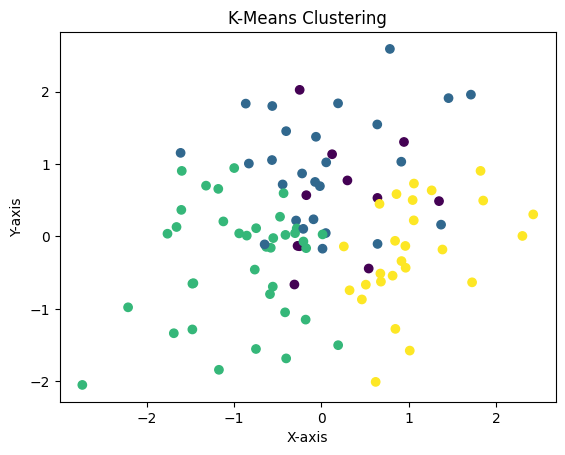

In [47]:
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt


def means(points, k=4, iters=100):
    # 随机初始化质心
    centroids = points[np.random.choice(len(points), k, replace=False)]
    
    for _ in range(iters):
        clusters = defaultdict(list)
        # 分配点到最近的质心
        for point in points:
            distances = np.linalg.norm(centroids - point, axis=1)
            closest_centroid = np.argmin(distances)
            clusters[closest_centroid].append(point)
        
        # 更新质心位置
        for i in range(k):
            if clusters[i]:  # 避免空簇
                centroids[i] = np.mean(clusters[i], axis=0)
    
    # 返回每个点所属的簇索引
    cluster_indices = np.zeros(len(points), dtype=int)
    for idx, point in enumerate(points):
        distances = np.linalg.norm(centroids - point, axis=1)
        cluster_indices[idx] = np.argmin(distances)
    
    return cluster_indices
    

points = np.random.randn(100, 3)
clusters = means(points, k=4, iters=100)
# draw clusters
plt.scatter(points[:, 0], points[:, 1], c=clusters)
plt.title("K-Means Clustering")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show()
    


In [1]:
import torch

# a = torch.tensor([1, 0,0,0,0,0,0,0])
a = torch.ones((8,))
a = (torch.rand(a.shape) > 0.9) * a
print(a)
adv = (a - torch.mean(a, dim=-1, keepdim=True)) / (torch.std(a, dim=-1, keepdim=True) + 1e-8)



tensor([0., 0., 0., 0., 0., 0., 0., 0.])


In [62]:
import numpy as np

x = np.random.rand(1000000)
y = np.random.rand(1000000)

val = (x**2 + y**2) <= 1


print(4 * val.sum() / len(x))


3.143284


In [3]:
import torch

a = torch.randn(2, 4, 8) # bsz, seq_len, hidden_size

def safe_softmax(logits):
    max_val = torch.max(logits, dim=-1, keepdim=True).values
    logits = torch.exp(logits - max_val)
    return logits / torch.sum(logits, dim=-1, keepdim=True)


def ce_loss(logits, targets):
    delta = logits - torch.logsumexp(logits, dim=-1, keepdim=True)
    print(targets.unsqueeze(-1).shape, delta.shape)
    return -torch.mean(torch.gather(delta, dim=-1, index=targets.unsqueeze(-1)).squeeze(-1))


logits = torch.randn(2, 4, 8)
targets = torch.randint(0, 8, (2, 4))
print(ce_loss(logits, targets))
# probs = safe_softmax(logits)
# print(probs)
    



torch.Size([2, 4, 1]) torch.Size([2, 4, 8])
tensor(2.2742)


[[ 1.04427082  1.81565541]
 [-1.55214401  1.01736775]
 [-0.32539067 -0.81969148]
 [-0.80851372  1.57967742]]


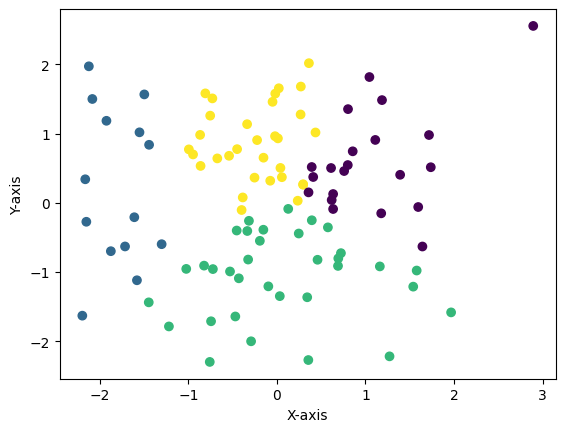

In [14]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict


def get_mean(points, k=4, iter=1000):
    center_points = points[np.random.randint(0, len(points), (k,))]
    print(center_points)
    for iter in range(iter):
        clusters = defaultdict(list)
        for point in points:
            dist = np.linalg.norm(point - center_points, axis=-1)
            min_idx = np.argmin(dist, axis=-1)
            clusters[min_idx].append(point)
        for i in range(k):
            center_points[i] = np.mean(clusters[i], axis=0)
    
    cluster_idxs = np.zeros(len(points), dtype=int)
    for idx, point in enumerate(points):
        dist = np.linalg.norm(point - center_points, axis=-1)
        min_idx = np.argmin(dist, axis=-1)
        cluster_idxs[idx] = min_idx     

    return cluster_idxs

rand_points = np.random.randn(100, 2)
clusters = get_mean(rand_points)
plt.scatter(rand_points[:, 0], rand_points[:, 1], c=clusters)

plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show()

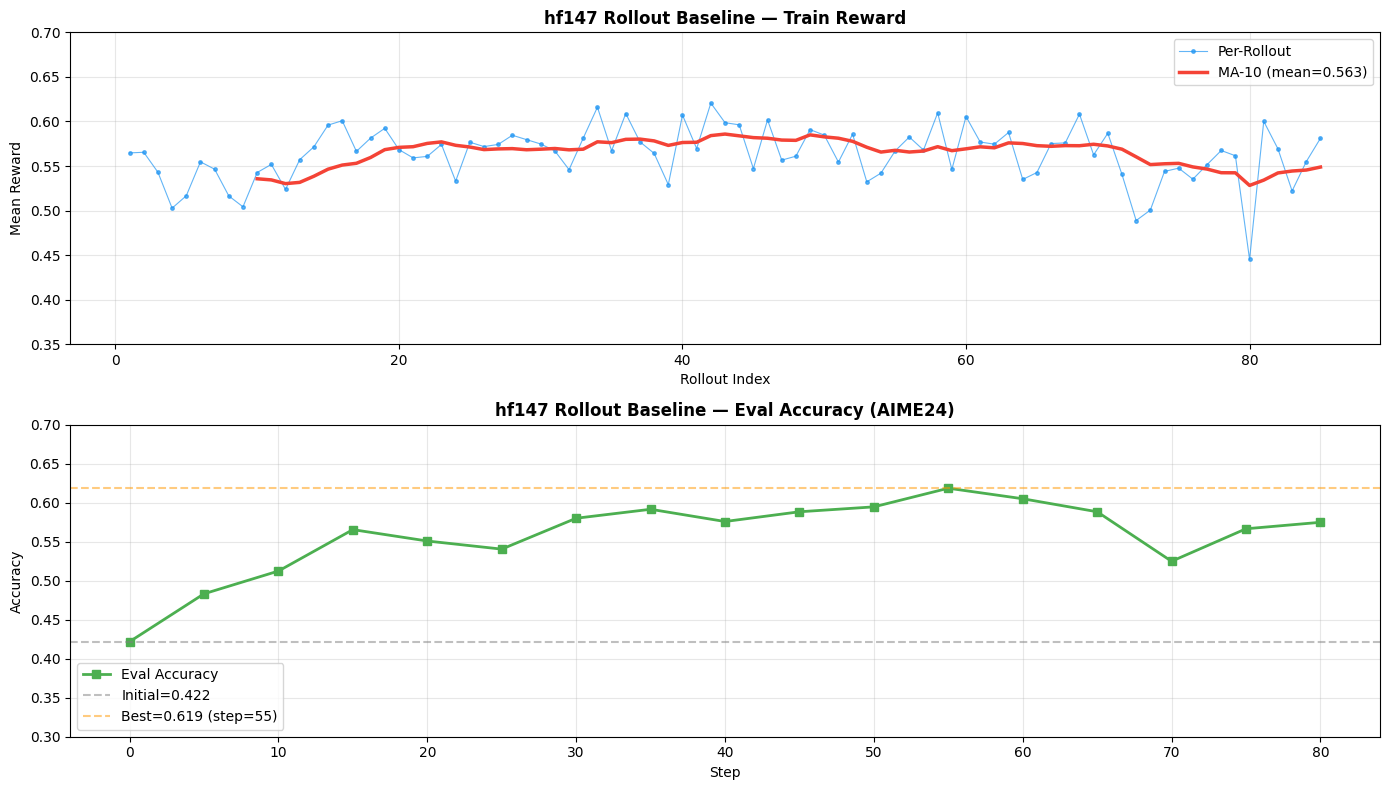

In [15]:

import matplotlib.pyplot as plt
import numpy as np

rollout_indices = list(range(1, 86))
rollout_rewards = [0.5647,0.5654,0.5430,0.5027,0.5166,0.5547,0.5464,0.5164,0.5042,0.5427,
0.5518,0.5237,0.5571,0.5715,0.5959,0.6008,0.5664,0.5813,0.5923,0.5684,
0.5591,0.5608,0.5742,0.5330,0.5767,0.5718,0.5742,0.5845,0.5796,0.5747,
0.5669,0.5459,0.5813,0.6160,0.5671,0.6089,0.5771,0.5642,0.5291,0.6072,
0.5696,0.6206,0.5986,0.5962,0.5471,0.6018,0.5566,0.5610,0.5908,0.5847,
0.5544,0.5857,0.5322,0.5420,0.5669,0.5825,0.5679,0.6096,0.5461,0.6055,
0.5769,0.5745,0.5876,0.5349,0.5427,0.5752,0.5759,0.6082,0.5625,0.5867,
0.5405,0.4888,0.5005,0.5439,0.5476,0.5352,0.5515,0.5674,0.5615,0.4451,
0.6001,0.5693,0.5220,0.5549,0.5811]

eval_steps = [0,5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80]
eval_accs = [0.4219,0.4833,0.5125,0.5656,0.5510,0.5406,0.5802,0.5917,0.5760,0.5885,0.5948,0.6187,0.6052,0.5885,0.5250,0.5667,0.5750]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

ax1.plot(rollout_indices, rollout_rewards, 'o-', color='#2196F3', ms=2.5, lw=0.8, alpha=0.7, label='Per-Rollout')
ma10 = np.convolve(rollout_rewards, np.ones(10)/10, mode='valid')
ax1.plot(rollout_indices[9:], ma10, '-', color='#F44336', lw=2.5, label=f'MA-10 (mean={np.mean(rollout_rewards):.3f})')
ax1.set_xlabel('Rollout Index'); ax1.set_ylabel('Mean Reward')
ax1.set_title('hf147 Rollout Baseline — Train Reward', fontweight='bold')
ax1.legend(); ax1.set_ylim(0.35, 0.70); ax1.grid(True, alpha=0.3)

ax2.plot(eval_steps, eval_accs, 's-', color='#4CAF50', ms=6, lw=2, label='Eval Accuracy')
ax2.axhline(y=eval_accs[0], color='gray', ls='--', alpha=0.5, label=f'Initial={eval_accs[0]:.3f}')
ax2.axhline(y=max(eval_accs), color='#FF9800', ls='--', alpha=0.5, label=f'Best={max(eval_accs):.3f} (step={eval_steps[eval_accs.index(max(eval_accs))]})')
ax2.set_xlabel('Step'); ax2.set_ylabel('Accuracy')
ax2.set_title('hf147 Rollout Baseline — Eval Accuracy (AIME24)', fontweight='bold')
ax2.legend(); ax2.set_ylim(0.3, 0.7); ax2.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from typing import Optional

# ==================== RoPE ====================

def precompute_freqs_cis(dim: int, end: int = int(32 * 1024), rope_base: float = 1e6,
                         rope_scaling: Optional[dict] = None, device: torch.device = None):
    freqs = 1.0 / (rope_base ** (torch.arange(0, dim, 2, device=device)[: (dim // 2)].float() / dim))
    freqs = freqs.to(device)
    if rope_scaling is not None:
        orig_max = rope_scaling.get("original_max_position_embeddings", 2048)
        factor = rope_scaling.get("factor", 4)
        beta_fast = rope_scaling.get("beta_fast", 4.0)
        beta_slow = rope_scaling.get("beta_slow", 1.0)
        if end / orig_max > 1.0:
            corr_dim = next((i for i in range(dim // 2) if 2 * math.pi / freqs[i] > orig_max), dim // 2)
            power = torch.arange(0, dim // 2, device=freqs.device).float() / max(dim // 2 - 1, 1)
            beta = beta_slow + (beta_fast - beta_slow) * power
            scale = torch.where(
                torch.arange(dim // 2, device=freqs.device) < corr_dim,
                (beta * factor - beta + 1) / (beta * factor),
                1.0 / factor,
            )
            freqs = freqs * scale
    t = torch.arange(end, device=freqs.device)
    freqs = torch.outer(t, freqs).float()
    freqs_cos = torch.cat([torch.cos(freqs), torch.cos(freqs)], dim=-1)
    freqs_sin = torch.cat([torch.sin(freqs), torch.sin(freqs)], dim=-1)
    return freqs_cos, freqs_sin


def apply_rotary_pos_emb(q, k, cos, sin):
    def rotate_half(x):
        return torch.cat((-x[..., x.shape[-1] // 2:], x[..., : x.shape[-1] // 2]), dim=-1)
    return q * cos + rotate_half(q) * sin, k * cos + rotate_half(k) * sin


# ==================== RMSNorm ====================

class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(dim))
        self.eps = eps

    def forward(self, x):
        return x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps) * self.weight


# ==================== Attention ====================

class Attention(nn.Module):
    def __init__(self, hidden_dim, num_q_head, num_kv_head, dropout=0.0):
        super().__init__()
        self.num_q_head = num_q_head
        self.num_kv_head = num_kv_head
        self.head_dim = hidden_dim // num_q_head
        self.q_proj = nn.Linear(hidden_dim, num_q_head * self.head_dim, bias=False)
        self.k_proj = nn.Linear(hidden_dim, num_kv_head * self.head_dim, bias=False)
        self.v_proj = nn.Linear(hidden_dim, num_kv_head * self.head_dim, bias=False)
        self.o_proj = nn.Linear(num_q_head * self.head_dim, hidden_dim, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, attention_mask=None, kv_cache=None):
        bsz, in_seq_len, _ = x.shape
        q = self.q_proj(x).reshape(bsz, in_seq_len, self.num_q_head, self.head_dim).transpose(1, 2)
        k = self.k_proj(x).reshape(bsz, in_seq_len, self.num_kv_head, self.head_dim).transpose(1, 2)
        v = self.v_proj(x).reshape(bsz, in_seq_len, self.num_kv_head, self.head_dim).transpose(1, 2)

        # 位置偏移 (decode 时从 cache 长度开始)
        start_pos = kv_cache[0].size(2) if kv_cache is not None else 0

        # RoPE: 取对应位置的 freqs
        freqs_cos, freqs_sin = precompute_freqs_cis(
            self.head_dim, start_pos + in_seq_len, device=x.device
        )
        freqs_cos = freqs_cos[start_pos: start_pos + in_seq_len]
        freqs_sin = freqs_sin[start_pos: start_pos + in_seq_len]
        q, k = apply_rotary_pos_emb(q, k, freqs_cos, freqs_sin)

        # KV Cache (RoPE 之后)
        if kv_cache is not None:
            kv_cache[0] = torch.cat([kv_cache[0], k], dim=2)
            kv_cache[1] = torch.cat([kv_cache[1], v], dim=2)
            k, v = kv_cache

        kv_len = k.size(2)

        # GQA: 扩展 k, v 到 num_q_head
        n_rep = self.num_q_head // self.num_kv_head
        if n_rep > 1:
            k = k.repeat_interleave(n_rep, dim=1)
            v = v.repeat_interleave(n_rep, dim=1)

        # Score
        score = q @ k.transpose(-2, -1) / (self.head_dim ** 0.5)

        # Padding mask
        if attention_mask is not None:
            score = score.masked_fill(attention_mask == 0, float('-inf'))

        # Causal mask (仅 prefill)
        if in_seq_len > 1:
            causal_mask = torch.triu(
                torch.full((in_seq_len, kv_len), float('-inf'), device=x.device),
                diagonal=kv_len - in_seq_len + 1,
            )
            score = score + causal_mask

        attn_weights = torch.softmax(score, dim=-1)
        attn_weights = self.dropout(attn_weights)

        out = (attn_weights @ v).transpose(1, 2).reshape(bsz, in_seq_len, -1)
        return self.o_proj(out), kv_cache


# ==================== SwiGLU FFN ====================

class SwiGLU(nn.Module):
    def __init__(self, hidden_dim, intermediate_dim=None):
        super().__init__()
        if intermediate_dim is None:
            intermediate_dim = ((int(hidden_dim * 8 / 3) + 255) // 256) * 256
        self.gate_proj = nn.Linear(hidden_dim, intermediate_dim, bias=False)
        self.up_proj = nn.Linear(hidden_dim, intermediate_dim, bias=False)
        self.down_proj = nn.Linear(intermediate_dim, hidden_dim, bias=False)
    
    def silu(self, x):
        return x * torch.sigmoid(x)

    def forward(self, x):
        return self.down_proj(self.silu(self.gate_proj(x)) * self.up_proj(x))


# ==================== Decoder Layer ====================

class DecoderLayer(nn.Module):
    def __init__(self, hidden_dim, num_q_head, num_kv_head, intermediate_dim=None):
        super().__init__()
        self.attn_norm = RMSNorm(hidden_dim)
        self.attn = Attention(hidden_dim, num_q_head, num_kv_head)
        self.ffn_norm = RMSNorm(hidden_dim)
        self.ffn = SwiGLU(hidden_dim, intermediate_dim)

    def forward(self, x, attention_mask=None, kv_cache=None):
        h = self.attn_norm(x)
        attn_out, kv_cache = self.attn(h, attention_mask, kv_cache)
        x = x + attn_out
        h = self.ffn_norm(x)
        x = x + self.ffn(h)
        return x, kv_cache


# ==================== Decoder ====================

class Decoder(nn.Module):
    def __init__(self, vocab_size, hidden_dim, num_layers, num_q_head, num_kv_head,
                 intermediate_dim=None, max_seq_len=4096):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.num_kv_head = num_kv_head
        self.head_dim = hidden_dim // num_q_head

        self.embed_tokens = nn.Embedding(vocab_size, hidden_dim)
        self.layers = nn.ModuleList([
            DecoderLayer(hidden_dim, num_q_head, num_kv_head, intermediate_dim)
            for _ in range(num_layers)
        ])
        self.norm = RMSNorm(hidden_dim)
        self.lm_head = nn.Linear(hidden_dim, vocab_size, bias=False)
        self.lm_head.weight = self.embed_tokens.weight  # weight tying

    def init_kv_cache(self, bsz, device=None):
        return [
            [
                torch.zeros(bsz, self.num_kv_head, 0, self.head_dim, device=device),
                torch.zeros(bsz, self.num_kv_head, 0, self.head_dim, device=device),
            ]
            for _ in range(self.num_layers)
        ]

    def forward(self, input_ids, attention_mask=None, kv_caches=None):
        x = self.embed_tokens(input_ids)

        if kv_caches is None:
            kv_caches = [None] * self.num_layers

        new_caches = []
        for i, layer in enumerate(self.layers):
            x, cache = layer(x, attention_mask, kv_caches[i])
            new_caches.append(cache)

        x = self.norm(x)
        return self.lm_head(x), new_caches


# ==================== 测试 ====================

# 超参 (LLaMA-1B 级别)
H, L, Q, KV, V = 2048, 16, 32, 8, 32000
model = Decoder(V, H, L, Q, KV)

# Prefill
ids = torch.randint(0, V, (2, 64))
logits, caches = model(ids)
print(f"prefill logits: {logits.shape}")  # (2, 64, 32000)

# Decode step
kv = model.init_kv_cache(2)
# 先 prefill 填充 cache
_, kv = model(ids[:, :32], kv_caches=kv)
_, kv = model(ids[:, 32:33], kv_caches=kv)
print(f"kv cache len after decode: {kv[0][0].size(2)}")  # 33

prefill logits: torch.Size([2, 64, 32000])
kv cache len after decode: 33


In [ ]:
import torch
import torch.nn.functional as F
from torch import nn
from typing import List, Dict

class OnPolicyDistillation:
    def __init__(
        self,
        student_model: nn.Module,          # 学生模型 (当前策略 π_θ)
        teacher_models: List[nn.Module],   # 教师模型列表 (π_Ei)
        teacher_weights: List[float],      # 每个教师对应的权重 w_i
        temperature: float = 1.0,
    ):
        self.student = student_model
        self.teachers = teacher_models
        self.weights = teacher_weights
        self.temperature = temperature
        
        # 确保权重数量与教师数量一致
        assert len(self.teachers) == len(self.weights)

    def _get_logits(
        self, 
        model: nn.Module, 
        input_ids: torch.Tensor, 
        attention_mask: torch.Tensor
    ) -> torch.Tensor:
        """获取模型在当前输入序列上的全词表 logits（带温度调节）"""
        with torch.no_grad() if model is not self.student else torch.enable_grad():
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
            )
            logits = outputs.logits / self.temperature   # [batch, seq_len, vocab_size]
        return logits

    def compute_opd_loss(
        self,
        on_policy_ids: torch.Tensor,      # 学生模型生成的 on-policy 序列 [B, L]
        attention_mask: torch.Tensor,     # [B, L]
    ) -> torch.Tensor:
        """
        根据已经采样好的 on-policy 轨迹，计算 OPD 损失：
        L = Σ_i w_i * D_KL(π_θ || π_Ei)
        """
        total_loss = 0.0
        
        # 学生 logits（需要梯度）
        student_logits = self._get_logits(self.student, on_policy_ids, attention_mask)
        student_log_probs = F.log_softmax(student_logits, dim=-1)
        student_probs = F.softmax(student_logits, dim=-1)
        
        # 逐教师计算反向 KL 散度
        for teacher, weight in zip(self.teachers, self.weights):
            teacher_logits = self._get_logits(teacher, on_policy_ids, attention_mask)
            teacher_log_probs = F.log_softmax(teacher_logits, dim=-1)
            
            # D_KL( student || teacher ) = Σ_x p_student(x) * (log p_student(x) - log p_teacher(x))
            # 在序列维度求和后求平均
            kl_per_token = torch.sum(
                student_probs * (student_log_probs - teacher_log_probs), dim=-1
            )  # [B, L]
            # 只对有效 token（非 padding）部分计算损失
            masked_kl = kl_per_token * attention_mask
            loss = masked_kl.sum() / attention_mask.sum()
            
            total_loss += weight * loss
            
        return total_loss

    def training_step(
        self,
        prompts: torch.Tensor,           # 输入提示 [B, L_prompt]
        max_new_tokens: int,
        optimizer: torch.optim.Optimizer,
    ) -> float:
        """单步 OPD 训练：采样 -> 计算损失 -> 更新"""
        self.student.eval()  # 采样时学生模型处于 eval 模式
        self.teachers = [t.eval() for t in self.teachers]  # 教师永远 eval
        
        # 1. 从学生策略中采样获得 on-policy 序列
        with torch.no_grad():
            generated = self.student.generate(
                prompts,
                max_new_tokens=max_new_tokens,
                do_sample=True,
                temperature=self.temperature,
                pad_token_id=0
            )
        
        # 构建 attention mask（假设 padding 在左侧或右侧，简单处理为全1）
        attention_mask = (generated != 0).float()
        
        self.student.train()  # 学生模型切回训练模式
        
        # 2. 计算 OPD 损失（学生部分需要梯度）
        loss = self.compute_opd_loss(generated, attention_mask)
        
        # 3. 反向传播与优化器更新
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        return loss.item()


# ----------------- 使用示例 -----------------
# 假设已经定义了 student_model, teacher_list, weights
# opd_trainer = OnPolicyDistillation(student_model, teacher_list, weights, temperature=1.0)
# optimizer = torch.optim.AdamW(student_model.parameters(), lr=1e-5)
#
# for batch_prompts in dataloader:
#     loss = opd_trainer.training_step(batch_prompts, max_new_tokens=128, optimizer=optimizer)
#     print(f"OPD loss: {loss}")

In [ ]:
import torch
from vllm import LLM, SamplingParams


prompts = [
    "请用中文介绍一下你自己。",
    "什么是机器学习？"
]

model = LLM(model="Qwen/Qwen2.5-7B-Instruct", tensor_parallel_size=1, max_model_len=4096, gpu_memory_utilization=0.9)

outputs = model.generate(prompts, SamplingParams(temperature=0.7, top_p=0.9, max_tokens=512))

for o in outputs:
    print(o.outputs[0].text)
    
    
    
